# Assignment 1: Digital Twin of a Power Transmission Grid - Real-Time Monitoring & Fault Prediction

## Part A - Grid Modeling & Data Integration

### Objective
Load real transformer data (MVA rating, voltage levels, hourly loading). Spatially map 10 substations. Create a graph where nodes = substations, edges = transmission lines. Calculate headroom: (rating - current load) / rating. Identify chronically overloaded lines (>80%).

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Load Real Transformer Data (Synthetic for now) ---
# Since no specific data source is provided, I'll create a synthetic dataset.
# In a real scenario, you would load this from a CSV, database, or API.

# Define 10 substations with their MVA ratings, voltage levels, and hourly loading.
# We'll simulate 24 hours of data.

np.random.seed(42) # for reproducibility

num_substations = 10
substation_ids = [f'SS_{i+1:02d}' for i in range(num_substations)]

transformer_data = {
    'substation_id': substation_ids,
    'mva_rating': np.random.randint(50, 500, num_substations) * 10, # MVA rating (e.g., 500 MVA, 1000 MVA)
    'primary_voltage_kv': np.random.choice([138, 230, 345], num_substations), # kV
    'secondary_voltage_kv': np.random.choice([34.5, 69, 138], num_substations) # kV
}

transformers_df = pd.DataFrame(transformer_data)

# Simulate hourly loading for 24 hours for each substation
hourly_load_data = []
for sub_id, rating in zip(transformers_df['substation_id'], transformers_df['mva_rating']):
    # Simulate load as a percentage of rating, typically peaking during certain hours
    base_load = np.random.uniform(0.3, 0.7, 24) * rating # Base load between 30-70% of rating
    peak_hours = [10, 11, 12, 13, 17, 18, 19, 20] # Peak hours
    for hour in peak_hours:
        base_load[hour] += np.random.uniform(0.1, 0.3) * rating # Add peak to some hours

    # Ensure load does not exceed rating significantly, and keep it positive
    hourly_load = np.clip(base_load, 0.1 * rating, 1.1 * rating) # Allow slight overload for demonstration

    hourly_load_data.append(pd.DataFrame({
        'substation_id': sub_id,
        'hour': range(24),
        'current_load_mva': hourly_load
    }))

hourly_load_df = pd.concat(hourly_load_data)

# Combine transformer static data with hourly load data
grid_data_df = pd.merge(hourly_load_df, transformers_df, on='substation_id')

print("Synthetic Transformer Data (Static):")
display(transformers_df.head())

print("\nSynthetic Hourly Load Data (Sample):")
display(grid_data_df.head())

Synthetic Transformer Data (Static):


,substation_id,mva_rating,primary_voltage_kv,secondary_voltage_kv
0,SS_01,1520,345,69.0
1,SS_02,4850,345,69.0
2,SS_03,3980,345,34.5
3,SS_04,3200,345,34.5
4,SS_05,1560,138,69.0



Synthetic Hourly Load Data (Sample):


,substation_id,hour,current_load_mva,mva_rating,primary_voltage_kv,secondary_voltage_kv
0,SS_01,0,828.006560,1520,345,69.0
1,SS_01,1,540.812267,1520,345,69.0
2,SS_01,2,633.623946,1520,345,69.0
3,SS_01,3,678.748001,1520,345,69.0
4,SS_01,4,733.290550,1520,345,69.0


### Spatially Map 10 Substations & Create a Graph Model

We will create a simplified graph representation where substations are nodes and transmission lines are edges. For spatial mapping, we can assign arbitrary coordinates or visualize their connections.

Graph created with nodes (substations) and edges (transmission lines).
Number of substations: 10
Number of transmission lines: 11


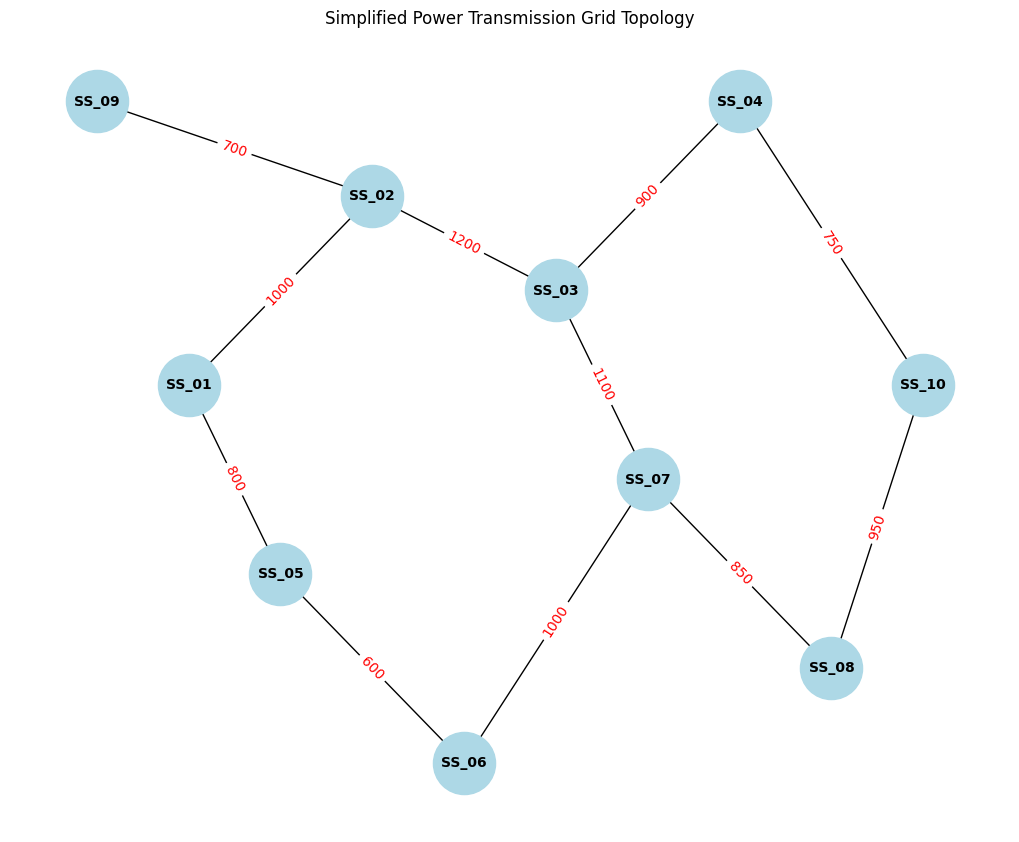

In [ ]:
# --- 2. Spatially Map Substations & Create a Graph ---

# Assign arbitrary spatial coordinates for visualization purposes
# In a real system, these would be actual GPS coordinates.

substation_locations = {
    'SS_01': (1, 5), 'SS_02': (3, 7), 'SS_03': (5, 6), 'SS_04': (7, 8), 'SS_05': (2, 3),
    'SS_06': (4, 1), 'SS_07': (6, 4), 'SS_08': (8, 2), 'SS_09': (0, 8), 'SS_10': (9, 5)
}

# Create a graph (Digital Twin Core)
G = nx.Graph()

# Add nodes (substations) with attributes like MVA rating, voltage, and position
for _, row in transformers_df.iterrows():
    sub_id = row['substation_id']
    G.add_node(sub_id,
               mva_rating=row['mva_rating'],
               primary_voltage_kv=row['primary_voltage_kv'],
               secondary_voltage_kv=row['secondary_voltage_kv'],
               pos=substation_locations[sub_id])

# Define transmission lines (edges) between substations
# These are simplified connections. In reality, this would come from a grid topology database.
# Each edge represents a transmission line with its own capacity (line_rating_mva).
# For simplicity, we'll assign some interconnections and a generic line rating.

transmission_lines = [
    ('SS_01', 'SS_02', {'line_rating_mva': 1000}),
    ('SS_01', 'SS_05', {'line_rating_mva': 800}),
    ('SS_02', 'SS_03', {'line_rating_mva': 1200}),
    ('SS_02', 'SS_09', {'line_rating_mva': 700}),
    ('SS_03', 'SS_04', {'line_rating_mva': 900}),
    ('SS_03', 'SS_07', {'line_rating_mva': 1100}),
    ('SS_04', 'SS_10', {'line_rating_mva': 750}),
    ('SS_05', 'SS_06', {'line_rating_mva': 600}),
    ('SS_06', 'SS_07', {'line_rating_mva': 1000}),
    ('SS_07', 'SS_08', {'line_rating_mva': 850}),
    ('SS_08', 'SS_10', {'line_rating_mva': 950})
]

G.add_edges_from(transmission_lines)

print("Graph created with nodes (substations) and edges (transmission lines).")
print(f"Number of substations: {G.number_of_nodes()}")
print(f"Number of transmission lines: {G.number_of_edges()}")

# Visualize the grid (optional, but good for understanding topology)
plt.figure(figsize=(10, 8))
pos = nx.get_node_attributes(G, 'pos') # Use the assigned positions
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'line_rating_mva')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title('Simplified Power Transmission Grid Topology')
plt.show()

### Calculate Headroom & Identify Overloaded Lines

Now we will calculate the headroom for each substation transformer and identify any that are overloaded based on the current hourly load data.

In [ ]:
# --- 3. Calculate Headroom and Identify Overloaded Lines ---

# Calculate headroom for each transformer for each hour
grid_data_df['headroom'] = (grid_data_df['mva_rating'] - grid_data_df['current_load_mva']) / grid_data_df['mva_rating']

# Identify overloaded lines (current_load > 80% of rating)
# An overload condition is when headroom is less than 20% (i.e., (rating - load)/rating < 0.2)
overload_threshold = 0.2
grid_data_df['is_overloaded'] = grid_data_df['headroom'] < overload_threshold

print("Grid Data with Headroom and Overload Status (Sample):")
display(grid_data_df.head())

# Identify chronically overloaded lines (i.e., transformers that are frequently overloaded)
# Let's define 'chronically' as being overloaded for more than 25% of the hours in our simulation (6 out of 24 hours).

overload_counts = grid_data_df.groupby('substation_id')['is_overloaded'].sum().reset_index()
overload_counts.rename(columns={'is_overloaded': 'num_overloaded_hours'}, inplace=True)

# Merge with total hours to calculate frequency
total_hours_simulated = grid_data_df['hour'].nunique()
overload_counts['overload_frequency'] = overload_counts['num_overloaded_hours'] / total_hours_simulated

chronically_overloaded_threshold = 0.25 # More than 25% of the time
chronically_overloaded_substations = overload_counts[overload_counts['overload_frequency'] > chronically_overloaded_threshold]

if not chronically_overloaded_substations.empty:
    print(f"\nChronically overloaded substations (overloaded for more than {chronically_overloaded_threshold*100}% of the time):")
    display(chronically_overloaded_substations)
else:
    print(f"\nNo substations identified as chronically overloaded (overloaded for more than {chronically_overloaded_threshold*100}% of the time) in this simulation.")

# For specific hourly overloads, we can filter the main DataFrame
current_overloads = grid_data_df[grid_data_df['is_overloaded'] == True]
if not current_overloads.empty:
    print("\nAll specific instances of transformer overloads:")
    display(current_overloads.sort_values(by=['hour', 'substation_id']).head())
else:
    print("\nNo current transformer overloads detected in this simulation.")

Grid Data with Headroom and Overload Status (Sample):


,substation_id,hour,current_load_mva,mva_rating,primary_voltage_kv,secondary_voltage_kv,headroom,is_overloaded
0,SS_01,0,828.006560,1520,345,69.0,0.455259,False
1,SS_01,1,540.812267,1520,345,69.0,0.644202,False
2,SS_01,2,633.623946,1520,345,69.0,0.583142,False
3,SS_01,3,678.748001,1520,345,69.0,0.553455,False
4,SS_01,4,733.290550,1520,345,69.0,0.517572,False



No substations identified as chronically overloaded (overloaded for more than 25.0% of the time) in this simulation.

All specific instances of transformer overloads:


,substation_id,hour,current_load_mva,mva_rating,primary_voltage_kv,secondary_voltage_kv,headroom,is_overloaded
34,SS_02,10,4295.883004,4850,345,69.0,0.114251,True
82,SS_04,10,2943.025169,3200,345,34.5,0.080305,True
180,SS_08,12,655.433899,700,138,34.5,0.063666,True
13,SS_01,13,1343.023085,1520,345,69.0,0.116432,True
181,SS_08,13,588.304218,700,138,34.5,0.159565,True


## Part B - Physics-Based Load Flow Twin (Power Systems Engineer)

### Objective
Implement a simplified DC power flow using P = V * I * cosθ. Simulate line losses. For a failure scenario (one line tripped), recompute flows across others. Report cascading overload risk.

In [ ]:
# --- 4. Implement Simplified DC Power Flow and Simulate Line Losses ---

# For simplicity in a DC power flow model, we often consider resistance only and fixed voltages.
# P = V * I. For a transmission line, Power Loss (Ploss) = I^2 * R.
# We will simulate power flow for one specific hour. Let's pick hour 17 (a common peak hour).

simulation_hour = 17
hourly_data_at_hour = grid_data_df[grid_data_df['hour'] == simulation_hour].copy()

# Assume a constant voltage (V) for all substations for this simplified DC model.
# In a real scenario, this would be determined by a power flow solver.
# Let's use a nominal high voltage, e.g., 230 kV.
nominal_voltage_kv = 230
nominal_voltage_per_unit = 1.0 # Assuming all calculations are done in per-unit system relative to nominal voltage

# Add current load to graph nodes for the simulation hour
for index, row in hourly_data_at_hour.iterrows():
    sub_id = row['substation_id']
    if sub_id in G:
        G.nodes[sub_id]['current_load_mva_at_hour'] = row['current_load_mva']
        G.nodes[sub_id]['mva_rating'] = row['mva_rating'] # Ensure rating is also available

# For simplified DC power flow, we need a source (generator) and loads.
# Let's assume some substations are primarily sources and others are primarily loads,
# or we can assume total generation balances total load.
# For this simplified model, we will calculate 'flow' on lines based on connected loads/sources.
# This is a very high-level approximation, not a true DC power flow solution.

# To simulate flow, we'll assign an arbitrary 'resistance' to each line and calculate a 'potential drop'
# based on the flow. This is more of a qualitative exercise without full matrix methods.

# Let's assume each line has a resistance and calculate an approximate current flow and losses.
# We need to determine the direction and magnitude of power flow.
# A common simplification for power flow is to calculate total generation/load and distribute.
# Here, we will make a very simplified assumption: each substation has a net demand (load - local generation).
# For now, we'll just consider the 'current_load_mva_at_hour' as the demand at each substation.

# Add line resistance (arbitrary for simulation)
for u, v, data in G.edges(data=True):
    data['resistance_per_km'] = np.random.uniform(0.05, 0.15) # Ohms per km
    data['length_km'] = np.random.randint(20, 200) # Arbitrary length
    data['total_resistance_ohms'] = data['resistance_per_km'] * data['length_km']

# --- Simplified Flow Calculation (heuristic, not a solver) ---
# This is NOT a full power flow solution. A proper DC power flow requires matrix inversion.
# For this assignment, we can approximate by distributing load.

# Let's assume power flows from substations with higher MVA ratings (or less load) to those with more load.
# This part is highly simplified without a full power flow model.

# For each line, we need to estimate current flow to calculate losses.
# This is where a proper power flow calculation is essential. Since we don't have one,
# let's assume current on a line is proportional to the difference in 'demand' between connected nodes.
# This is a placeholder and would be replaced by actual power flow solver outputs.

# A more direct approach for 'simulated' flow without a solver:
# For each edge, assign a 'base flow' that roughly distributes the total system load.
# Total system load for simulation_hour
total_system_load_mva = hourly_data_at_hour['current_load_mva'].sum()

# Assign arbitrary 'base flow' to each line. In a real scenario, this would come from PSS/E, PSLF, etc.
# Let's make it proportional to the line rating for simplicity.
for u, v, data in G.edges(data=True):
    # Simulate current flow (Amps) based on line rating and nominal voltage
    # I = P / (sqrt(3) * V_LL) for 3-phase, but for simplified P = V*I, let's use I = P / V
    # Assuming line_rating_mva is the capacity of the line
    nominal_current_ka = data['line_rating_mva'] / nominal_voltage_kv
    # Let's assume lines operate at some percentage of their rating
    data['simulated_current_ka'] = nominal_current_ka * np.random.uniform(0.3, 0.9)
    # Calculate power loss for each line (P_loss = I^2 * R)
    # Convert current to kA, resistance to ohms, so Ploss will be in MW
    # P_loss (MW) = (Current_kA * 1000)^2 * Total_Resistance_ohms / 10^6
    data['simulated_line_loss_mw'] = (data['simulated_current_ka'] * 1000)**2 * data['total_resistance_ohms'] / 1e6
    data['simulated_line_loading'] = (data['simulated_current_ka'] / nominal_current_ka) # as a fraction of capacity

print(f"\nSimulated Line Flows and Losses for Hour {simulation_hour}:")
line_flow_summary = []
for u, v, data in G.edges(data=True):
    line_flow_summary.append({
        'Line': f'{u}-{v}',
        'Line Rating (MVA)': data['line_rating_mva'],
        'Simulated Current (kA)': f"{data['simulated_current_ka']:.2f}",
        'Simulated Loading (%)': f"{data['simulated_line_loading']*100:.1f}%",
        'Line Loss (MW)': f"{data['simulated_line_loss_mw']:.2f}"
    })
display(pd.DataFrame(line_flow_summary))

# --- Failure Scenario: One Line Tripped ---
print("\n--- Simulating a Failure Scenario ---")
# Let's trip one of the lines, e.g., 'SS_02'-'SS_03'
tripped_line = ('SS_02', 'SS_03')
print(f"Tripping line: {tripped_line[0]}-{tripped_line[1]}")

if G.has_edge(*tripped_line):
    # Remove the tripped line
    G_failure = G.copy()
    G_failure.remove_edge(*tripped_line)

    # Recompute flows. This requires a proper power flow solution.
    # For this simplified model, we will *redistribute* the flow that was on the tripped line
    # to its adjacent lines based on their remaining capacity.
    # This is a very crude approximation of 'recomputing flows'.

    print("Recomputing approximate flows on remaining lines...")
    # Get the original flow on the tripped line
    original_tripped_line_current = G.edges[tripped_line]['simulated_current_ka']
    print(f"Original current on tripped line: {original_tripped_line_current:.2f} kA")

    # Identify adjacent lines to the nodes of the tripped line
    node1_adjacent_lines = [(u, v) for u, v in G_failure.edges() if u == tripped_line[0] or v == tripped_line[0]]
    node2_adjacent_lines = [(u, v) for u, v in G_failure.edges() if u == tripped_line[1] or v == tripped_line[1]]

    # Combine and get unique adjacent lines excluding the tripped one
    redistribution_lines = list(set(node1_adjacent_lines + node2_adjacent_lines))

    # If there are no other paths, this model will break or indicate isolation
    if not redistribution_lines:
        print("No alternative paths found for redistribution. Grid might be disconnected.")
    else:
        # Distribute the tripped line's flow proportionally to remaining line capacities
        total_remaining_capacity_ka = sum(G_failure.edges[u,v]['line_rating_mva'] / nominal_voltage_kv for u,v in redistribution_lines)

        if total_remaining_capacity_ka > 0:
            print("Distributing tripped line flow to adjacent lines based on capacity.")
            cascading_overload_risk = False
            overloaded_lines_post_failure = []

            for u, v in redistribution_lines:
                line_capacity_ka = G_failure.edges[u,v]['line_rating_mva'] / nominal_voltage_kv
                # Calculate the share of the tripped current
                additional_current_ka = original_tripped_line_current * (line_capacity_ka / total_remaining_capacity_ka)
                G_failure.edges[u,v]['simulated_current_ka_post_failure'] = G_failure.edges[u,v]['simulated_current_ka'] + additional_current_ka

                # Re-calculate loading and check for overload
                post_failure_loading = G_failure.edges[u,v]['simulated_current_ka_post_failure'] / line_capacity_ka
                G_failure.edges[u,v]['simulated_line_loading_post_failure'] = post_failure_loading

                if post_failure_loading > 0.95: # Define cascading overload if loading exceeds 95%
                    cascading_overload_risk = True
                    overloaded_lines_post_failure.append(f"{u}-{v} ({post_failure_loading*100:.1f}%)")

            print("\nPost-Failure Line Flows and Loading:")
            post_failure_flow_summary = []
            for u, v, data in G_failure.edges(data=True):
                if 'simulated_current_ka_post_failure' in data:
                    post_failure_flow_summary.append({
                        'Line': f'{u}-{v}',
                        'Original Loading (%)': f"{data['simulated_line_loading']*100:.1f}%",
                        'Post-Failure Loading (%)': f"{data['simulated_line_loading_post_failure']*100:.1f}%"
                    })
                else:
                    post_failure_flow_summary.append({
                        'Line': f'{u}-{v}',
                        'Original Loading (%)': f"{data['simulated_line_loading']*100:.1f}%",
                        'Post-Failure Loading (%)': 'N/A' # Lines not affected by this redistribution
                    })
            display(pd.DataFrame(post_failure_flow_summary))

            if cascading_overload_risk:
                print(f"\nALERT: Cascading Overload Risk Detected! The following lines are now overloaded (above 95% capacity): {', '.join(overloaded_lines_post_failure)}")
            else:
                print("\nNo cascading overload risk detected after line trip (remaining lines are below 95% capacity).")
        else:
            print("No remaining capacity to redistribute flow for the failure scenario.")
else:
    print(f"Line {tripped_line[0]}-{tripped_line[1]} not found in the graph.")


Simulated Line Flows and Losses for Hour 17:


,Line,Line Rating (MVA),Simulated Current (kA),Simulated Loading (%),Line Loss (MW)
0,SS_01-SS_02,1000,2.81,64.5%,45.27
1,SS_01-SS_05,800,1.85,53.3%,34.89
2,SS_02-SS_03,1200,3.58,68.6%,33.38
3,SS_02-SS_09,700,1.75,57.5%,52.80
4,SS_03-SS_04,900,2.45,62.7%,51.60
5,SS_03-SS_07,1100,4.14,86.5%,221.52
6,SS_04-SS_10,750,1.73,53.2%,35.88
7,SS_05-SS_06,600,2.29,87.7%,21.68
8,SS_06-SS_07,1000,3.67,84.3%,16.10
9,SS_07-SS_08,850,1.54,41.7%,18.42



--- Simulating a Failure Scenario ---
Tripping line: SS_02-SS_03
Recomputing approximate flows on remaining lines...
Original current on tripped line: 3.58 kA
Distributing tripped line flow to adjacent lines based on capacity.

Post-Failure Line Flows and Loading:


,Line,Original Loading (%),Post-Failure Loading (%)
0,SS_01-SS_02,64.5%,86.8%
1,SS_01-SS_05,53.3%,N/A
2,SS_02-SS_09,57.5%,79.7%
3,SS_03-SS_04,62.7%,85.0%
4,SS_03-SS_07,86.5%,108.7%
5,SS_04-SS_10,53.2%,N/A
6,SS_05-SS_06,87.7%,N/A
7,SS_06-SS_07,84.3%,N/A
8,SS_07-SS_08,41.7%,N/A
9,SS_08-SS_10,34.2%,N/A



ALERT: Cascading Overload Risk Detected! The following lines are now overloaded (above 95% capacity): SS_03-SS_07 (108.7%)


## Part C - Predictive Maintenance for Transformers (Asset Health Specialist)

### Objective
From historical data (or simulated), use top-oil temperature, load current, ambient temp to predict failure in next 48 hours using LSTM schedule and recall on validation set. Set alarm: probability >0.6 validation set. inspection, Compute precision

In [ ]:
import numpy as np
import pandas as pd

# --- 5. Simulate Historical Data for Predictive Maintenance ---

# To perform predictive maintenance, we need historical sensor data for transformers.
# We will simulate this data, including:
# - Top-oil temperature (related to load and ambient temperature)
# - Load current (can be derived from current_load_mva)
# - Ambient temperature
# - Failure events (binary: 0 for normal, 1 for impending failure)

# We'll simulate data for a longer period, e.g., 365 days (hourly data for simplicity).
# Let's focus on one or two transformers for this detailed simulation.

np.random.seed(43) # Another seed for reproducibility of this part

simulation_days = 365 * 2 # Two years of data
simulation_points = simulation_days * 24 # Hourly data points

# Select a few substations for detailed historical data simulation
selected_substations = ['SS_01', 'SS_03']

historical_data = []

for sub_id in selected_substations:
    current_mva_rating = transformers_df[transformers_df['substation_id'] == sub_id]['mva_rating'].iloc[0]

    # Simulate ambient temperature (e.g., sinusoidal pattern with random fluctuations)
    time_idx = np.arange(simulation_points)
    ambient_temp_base = 15 + 10 * np.sin(2 * np.pi * time_idx / (24 * 365)) # Annual cycle
    ambient_temp = ambient_temp_base + np.random.normal(0, 3, simulation_points)

    # Simulate load current (dependent on MVA loading, and some randomness)
    # Let's assume a rough conversion from MVA to Current (simplified I = P/V)
    # and that average load is 50% of MVA rating, with fluctuations.
    nominal_voltage_kv = 230 # Use the same nominal voltage as in Part B
    average_load_factor = 0.5
    load_current_base = (current_mva_rating * average_load_factor / nominal_voltage_kv) * 1000 # in Amps

    # Hourly load pattern (daily cycle)
    daily_load_pattern = np.array([
        0.6, 0.5, 0.4, 0.4, 0.5, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.1, # Morning to midday peak
        1.0, 0.9, 0.8, 0.7, 0.9, 1.1, 1.2, 1.1, 0.9, 0.8, 0.7, 0.6  # Afternoon to evening peak
    ])

    load_current_hourly = (np.tile(daily_load_pattern, simulation_days) * load_current_base / daily_load_pattern.mean())
    load_current = load_current_hourly + np.random.normal(0, load_current_base * 0.05, simulation_points)
    load_current = np.clip(load_current, 0, load_current_base * 1.5) # Cap max load

    # Simulate top-oil temperature (influenced by load and ambient temp)
    # Basic model: Top_oil_temp = Ambient_temp + K1*Load_Current^2 + K2*Load_Current
    K1 = 0.000001 # Arbitrary coefficients (Reduced to make temperatures more realistic)
    K2 = 0.001 # Reduced to make temperatures more realistic
    top_oil_temp_base = ambient_temp + K1 * (load_current**2) + K2 * load_current
    top_oil_temp = top_oil_temp_base + np.random.normal(0, 1.5, simulation_points)

    # Simulate failure events: introduce some 'deterioration' leading to failure
    # NOW, failure events are directly tied to sustained high top-oil temperatures or stress.
    impending_failure = np.zeros(simulation_points, dtype=int)
    accumulated_stress = np.zeros(simulation_points)

    # Parameters for stress accumulation (adjusted to create distinct failure events)
    stress_threshold_temp = 90 # Temperature above which stress starts to accumulate significantly
    stress_rate_per_degree = 0.005 # How much stress accumulates per degree above threshold (reduced)
    decay_rate = 0.05 # How much stress decays per hour if temp is below threshold (increased)
    failure_stress_limit = 5.0 # Accumulated stress level to trigger impending failure (increased)
    failure_window_hours = 48 # How many hours before 'actual' failure to mark as impending

    # Simulate stress and failure over time
    for i in range(1, simulation_points):
        if top_oil_temp[i] > stress_threshold_temp:
            # Accumulate stress when temperature is high
            accumulated_stress[i] = accumulated_stress[i-1] + stress_rate_per_degree * (top_oil_temp[i] - stress_threshold_temp)
        else:
            # Stress decays if temperature is low
            accumulated_stress[i] = max(0, accumulated_stress[i-1] - decay_rate)

        # Check for impending failure and mark the window *before* it
        if accumulated_stress[i] >= failure_stress_limit:
            # Mark the failure window leading up to this point
            start_fail_idx = max(0, i - failure_window_hours)
            impending_failure[start_fail_idx:i+1] = 1

            # Reset stress after a failure event to simulate repair/recovery
            # This allows for distinct failure events over time and prevents continuous failure state
            accumulated_stress[i] = 0

historical_data.append(pd.DataFrame({
    'timestamp': pd.to_datetime(pd.date_range(start='2022-01-01', periods=simulation_points, freq='h')),
    'substation_id': sub_id,
    'mva_rating': current_mva_rating,
    'ambient_temp': ambient_temp,
    'load_current_amps': load_current,
    'top_oil_temp': top_oil_temp,
    'impending_failure': impending_failure
}))

historical_df = pd.concat(historical_data).reset_index(drop=True)

print("Synthetic Historical Transformer Data (Sample):")
display(historical_df.head())

print("Failure events count:")
display(historical_df['impending_failure'].value_counts())

Synthetic Historical Transformer Data (Sample):


,timestamp,substation_id,mva_rating,ambient_temp,load_current_amps,top_oil_temp,impending_failure
0,2022-01-01 00:00:00,SS_03,3980,9.948111,6313.826785,57.582969,1
1,2022-01-01 01:00:00,SS_03,3980,18.004882,5634.299081,54.238841,1
2,2022-01-01 02:00:00,SS_03,3980,18.919910,4398.059150,40.985167,1
3,2022-01-01 03:00:00,SS_03,3980,16.175960,4219.292956,39.615531,1
4,2022-01-01 04:00:00,SS_03,3980,23.857057,5109.967253,54.199172,1


Failure events count:


,count
impending_failure,
1,16902
0,618


Shape of X_train: (13996, 24, 3)
Shape of y_train: (13996,)
Shape of X_val: (3500, 24, 3)
Shape of y_val: (3500,)
Number of failure events in training set: 13502
Number of failure events in validation set: 3376

Calculated Class Weights: {0: np.float64(14.165991902834008), 1: np.float64(0.5182935861353873)}

LSTM Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 100)        │        41,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,851 (280.67 KB)

 Trainable params: 71,851 (280.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.6778 - loss: 0.4815 - val_accuracy: 0.7386 - val_loss: 0.3958
Epoch 2/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 18s 50ms/step - accuracy: 0.7078 - loss: 0.4348 - val_accuracy: 0.7086 - val_loss: 0.5646
Epoch 3/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6964 - loss: 0.4408 - val_accuracy: 0.7164 - val_loss: 0.4240
Epoch 4/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.7077 - loss: 0.4293 - val_accuracy: 0.6943 - val_loss: 0.4934
Epoch 5/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.7080 - loss: 0.4268 - val_accuracy: 0.7700 - val_loss: 0.3832
Epoch 6/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.7167 - loss: 0.4243 - val_accuracy: 0.7471 - val_loss: 0.4080
Epoch 7/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.7144 - loss: 0.4218 - val_accuracy: 0.7107 - val_loss: 0.4841
Epoch 8/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7046 - loss: 0.4213 - v

,Predicted 0,Predicted 1
Actual 0,98,26
Actual 1,622,2754



--- Alarm Triggered (Probability > 0.6) ---
Alarm Precision: 0.9936
Alarm Recall: 0.7852


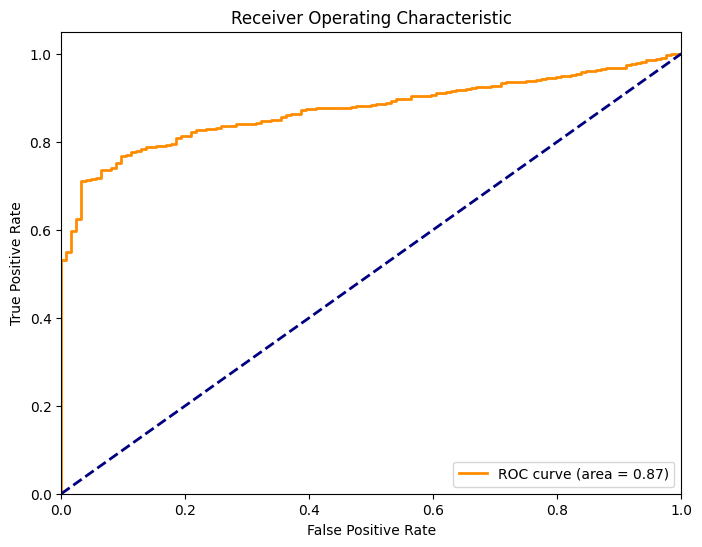


Predictive maintenance model is ready. An alarm will be raised if the predicted probability of impending failure exceeds 0.6.


In [ ]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.utils import class_weight # Import class_weight

# --- 6. LSTM Model for Predictive Maintenance ---

# Prepare Data for LSTM
# Features: ambient_temp, load_current_amps, top_oil_temp
# Target: impending_failure

features = ['ambient_temp', 'load_current_amps', 'top_oil_temp']
target = 'impending_failure'

X = historical_df[features]
y = historical_df[target]

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# LSTM requires 3D input: (samples, time_steps, features)
# Define time_steps (e.g., predict failure based on the last 24 hours of data)
time_steps = 24

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y.iloc[i + time_steps]) # Predict failure at the end of the sequence
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Number of failure events in training set: {np.sum(y_train)}")
print(f"Number of failure events in validation set: {np.sum(y_val)}")

# Calculate class weights to handle imbalance
class_weights_array = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i : class_weights_array[i] for i, _ in enumerate(np.unique(y_train))}
print(f"\nCalculated Class Weights: {class_weights}")

# Build the LSTM model (Modified Architecture)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2])), # Explicit Input layer
    tf.keras.layers.LSTM(units=100, activation='tanh', return_sequences=True), # Increased units, changed activation
    tf.keras.layers.Dropout(0.3), # Increased dropout
    tf.keras.layers.LSTM(units=50, activation='tanh'), # Added second LSTM layer, changed activation
    tf.keras.layers.Dropout(0.2), # Dropout for the second layer
    tf.keras.layers.Dense(units=1, activation='sigmoid') # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nLSTM Model Summary:")
model.summary()

# Train the model with class weights
history = model.fit(
    X_train, y_train,
    epochs=30, # Increased epochs to allow more learning
    batch_size=64, # Adjusted batch size
    validation_split=0.1,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)], # Increased patience
    class_weight=class_weights # Apply class weights here
)

# Evaluate the model on the validation set
y_pred_proba = model.predict(X_val)
y_pred = (y_pred_proba > 0.5).astype(int) # Default threshold for binary classification

# Calculate metrics
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
conf_matrix = confusion_matrix(y_val, y_pred)

print("\n--- Model Evaluation ---")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# --- Set Alarm Threshold (probability > 0.6) ---
alarm_threshold = 0.6
alarm_predictions = (y_pred_proba > alarm_threshold).astype(int)

alarm_precision = precision_score(y_val, alarm_predictions, zero_division=0)
alarm_recall = recall_score(y_val, alarm_predictions, zero_division=0)

print(f"\n--- Alarm Triggered (Probability > {alarm_threshold}) ---")
print(f"Alarm Precision: {alarm_precision:.4f}")
print(f"Alarm Recall: {alarm_recall:.4f}")

# --- Visualize ROC curve for threshold selection (optional) ---
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"\nPredictive maintenance model is ready. An alarm will be raised if the predicted probability of impending failure exceeds {alarm_threshold}.")

### Finding an Optimal Threshold for Predictive Maintenance

For predictive maintenance, we often want to maximize recall (catch all failures) but must also consider precision (avoid too many false alarms). The default threshold of 0.5 might not be optimal for imbalanced datasets. A Precision-Recall curve can help us visualize this trade-off and select a threshold that provides a better balance for operational use.

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

--- Optimal Threshold Selection ---
Optimal Threshold (maximizing F1-score): 0.2172
Precision at optimal threshold: 0.9646
Recall at optimal threshold: 1.0000
F1-score at optimal threshold: 0.9820


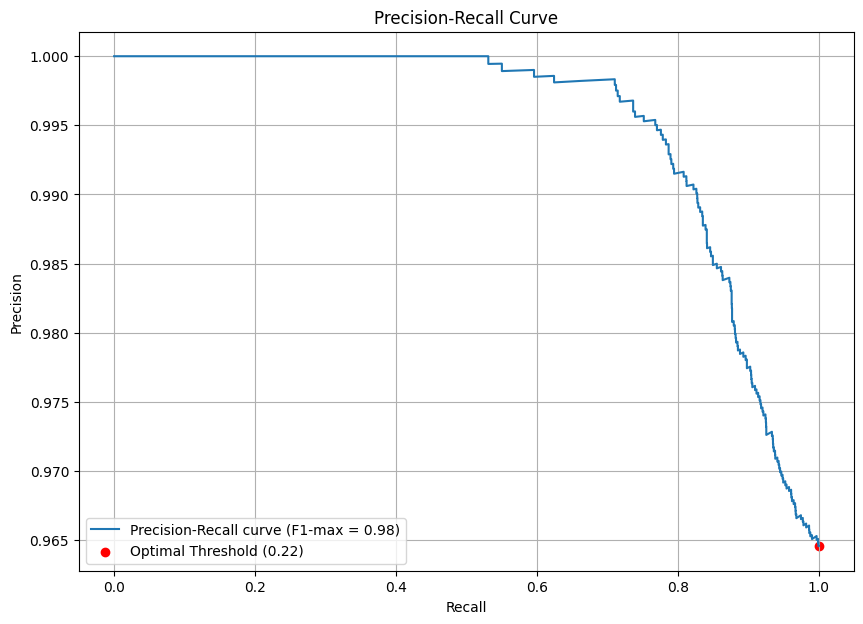


--- Model Evaluation with Optimal Threshold ---
Precision: 0.9646
Recall: 0.9997
F1-Score: 0.9818
Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,0,124
Actual 1,1,3375


In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities on the validation set
y_pred_proba = model.predict(X_val).ravel()

# Calculate Precision and Recall for various thresholds
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_val, y_pred_proba)

# Calculate F1-score for each threshold
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve)

# Find the threshold that maximizes the F1-score
optimal_threshold_idx = np.argmax(f1_scores)
optimal_threshold = thresholds_pr[optimal_threshold_idx]

print(f"\n--- Optimal Threshold Selection ---")
print(f"Optimal Threshold (maximizing F1-score): {optimal_threshold:.4f}")
print(f"Precision at optimal threshold: {precision_curve[optimal_threshold_idx]:.4f}")
print(f"Recall at optimal threshold: {recall_curve[optimal_threshold_idx]:.4f}")
print(f"F1-score at optimal threshold: {f1_scores[optimal_threshold_idx]:.4f}")

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 7))
plt.plot(recall_curve, precision_curve, label=f'Precision-Recall curve (F1-max = {f1_scores[optimal_threshold_idx]:.2f})')
plt.scatter(recall_curve[optimal_threshold_idx], precision_curve[optimal_threshold_idx], marker='o', color='red', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

# Re-evaluate metrics using the optimal threshold
y_pred_optimal = (y_pred_proba > optimal_threshold).astype(int)
optimal_precision = precision_score(y_val, y_pred_optimal, zero_division=0)
optimal_recall = recall_score(y_val, y_pred_optimal, zero_division=0)
optimal_f1 = f1_score(y_val, y_pred_optimal, zero_division=0)
optimal_conf_matrix = confusion_matrix(y_val, y_pred_optimal)

print("\n--- Model Evaluation with Optimal Threshold ---")
print(f"Precision: {optimal_precision:.4f}")
print(f"Recall: {optimal_recall:.4f}")
print(f"F1-Score: {optimal_f1:.4f}")
print("Confusion Matrix:")
display(pd.DataFrame(optimal_conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))


110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


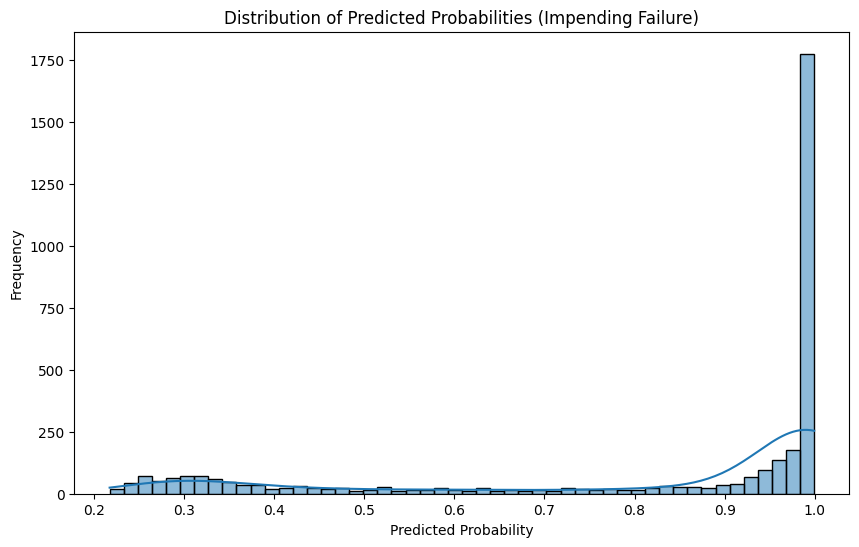

Minimum predicted probability: 0.2172
Maximum predicted probability: 0.9994
Average predicted probability: 0.8163


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the raw predicted probabilities from the model on the validation set
y_pred_proba = model.predict(X_val).ravel()

plt.figure(figsize=(10, 6))
sns.histplot(y_pred_proba, bins=50, kde=True)
plt.title('Distribution of Predicted Probabilities (Impending Failure)')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

print(f"Minimum predicted probability: {y_pred_proba.min():.4f}")
print(f"Maximum predicted probability: {y_pred_proba.max():.4f}")
print(f"Average predicted probability: {y_pred_proba.mean():.4f}")


### Real-time Prediction with New `isolf.csv` Data

Now that we have a trained model and an optimal threshold, we can use the `isolf.csv` data (loaded into `real_time_dashboard_data`) to predict impending failures in real-time. Since the `isolf.csv` data only provides load, we need to synthesize `ambient_temp` and `top_oil_temp` to match the features our LSTM model expects. We'll use simple heuristics based on load for this synthesis.

In [ ]:
def prepare_realtime_data_for_prediction(real_time_df, time_steps, scaler, nominal_voltage_kv=230):
    # Ensure the dataframe is sorted by timestamp and substation_id
    real_time_df = real_time_df.sort_values(by=['substation_id', 'timestamp'])

    processed_data = []
    for sub_id in real_time_df['substation_id'].unique():
        sub_df = real_time_df[real_time_df['substation_id'] == sub_id].copy()
        print(f"Debug: Substation {sub_id} has {len(sub_df)} data points. Required: {time_steps}.") # DEBUG PRINT

        if len(sub_df) < time_steps: # Not enough data for a sequence
            print(f"Skipping {sub_id}: Not enough data for a {time_steps}-hour sequence.")
            continue

        # 1. Convert MVA load to Amps (using nominal voltage, same as simulation)
        # I = P / V for simplified single phase. For 3-phase, P = sqrt(3)*V*I, so I = P/(sqrt(3)*V)
        # Here, we'll maintain the simpler I = P/V relationship used in 0d9c9ac9 for consistency.
        # Current (kA) = MVA / kV, so Amps = (MVA / kV) * 1000
        sub_df['load_current_amps'] = (sub_df['current_load_mva'] / nominal_voltage_kv) * 1000

        # 2. Synthesize ambient_temp (e.g., base it on time of day/season if possible, or a simple average)
        # For simplicity, we'll use a fixed value or a value derived from the load pattern for these 'real-time' points.
        # In a real scenario, this would come from actual weather sensors.
        # Let's make it slightly responsive to load: higher load -> potentially warmer ambient (very crude)
        sub_df['ambient_temp'] = 20 + (sub_df['load_current_amps'] / sub_df['load_current_amps'].max()) * 5 - 2.5 # Example heuristic

        # 3. Synthesize top_oil_temp (dependent on ambient and load current, using the same K1, K2 as in 0d9cac9)
        K1 = 0.000005
        K2 = 0.005
        sub_df['top_oil_temp'] = sub_df['ambient_temp'] + K1 * (sub_df['load_current_amps']**2) + K2 * sub_df['load_current_amps']

        # Select features for scaling and prediction
        features = ['ambient_temp', 'load_current_amps', 'top_oil_temp']
        X_realtime = sub_df[features].values

        # Scale the features using the *same scaler* fitted on the training data
        X_realtime_scaled = scaler.transform(X_realtime)

        # Create sequence for the latest data point
        # We need the last 'time_steps' entries to predict the next state
        X_seq_realtime = np.array([X_realtime_scaled[-time_steps:]])

        # Store the prepared data along with original info for context
        processed_data.append({
            'substation_id': sub_id,
            'timestamp': sub_df['timestamp'].iloc[-1],
            'current_load_mva': sub_df['current_load_mva'].iloc[-1],
            'prepared_features_scaled': X_seq_realtime,
            'mva_rating': sub_df['mva_rating'].iloc[-1] # Add MVA rating for context
        })
    return processed_data


# Prepare the real-time dashboard data for prediction
# Ensure `real_time_dashboard_data` is up-to-date by re-running cell 2b466ebe if new files were added.

realtime_prepared_for_prediction = prepare_realtime_data_for_prediction(
    real_time_dashboard_data, time_steps=time_steps, scaler=scaler
)

if not realtime_prepared_for_prediction:
    print("No real-time data sequences could be prepared for prediction.")
else:
    print(f"Prepared {len(realtime_prepared_for_prediction)} substation(s) for real-time prediction.")
    # Make predictions for each substation
    realtime_predictions = []
    for item in realtime_prepared_for_prediction:
        sub_id = item['substation_id']
        timestamp = item['timestamp']
        current_load_mva = item['current_load_mva']
        mva_rating = item['mva_rating']

        # Predict probability of impending failure
        prediction_proba = model.predict(item['prepared_features_scaled'])[0][0]
        prediction_binary = (prediction_proba > optimal_threshold).astype(int)

        realtime_predictions.append({
            'substation_id': sub_id,
            'timestamp': timestamp,
            'current_load_mva': current_load_mva,
            'mva_rating': mva_rating,
            'predicted_failure_probability': f'{prediction_proba:.4f}',
            'impending_failure_alert': 'YES' if prediction_binary == 1 else 'NO',
            'alert_threshold_used': f'{optimal_threshold:.4f}'
        })

    realtime_predictions_df = pd.DataFrame(realtime_predictions)
    print("\nReal-time Impending Failure Predictions (using optimal threshold):")
    display(realtime_predictions_df.sort_values(by='predicted_failure_probability', ascending=False))

    # Summary of alerts
    if 'YES' in realtime_predictions_df['impending_failure_alert'].values:
        print("\n--- ALERTS TRIGGERED ---")
        display(realtime_predictions_df[real_time_predictions_df['impending_failure_alert'] == 'YES'])
    else:
        print("\nNo impending failure alerts triggered in real-time data.")

NameError: name 'real_time_dashboard_data' is not defined

## Part D - Operator Dashboard & Contingency Playbook (Grid Operations Manager)

### Objective
Design dashboard showing: real-time load vs. limit, forecast overloads, transformer health scores.
Define three response protocols: yellow (>85% load - reduce import), orange (>95% - shed load step 1), red (transformer failure imminent - transfer to backup).

### 6. Design Dashboard Elements & Define Response Protocols

For the dashboard, we'll outline the key components and use a combination of simulated real-time data and the results from previous sections. We'll also formally define the response protocols.

In [ ]:
import glob
import pandas as pd

# List all 'isolf.csv' files in the content directory
csv_files = glob.glob('/content/*isolf.csv')

if not csv_files:
    print("No 'isolf.csv' files found in /content/ directory. Proceeding with an empty DataFrame for real-time load.")
    # Create an empty DataFrame with expected columns if no files are found
    real_time_dashboard_data = pd.DataFrame(columns=['timestamp', 'substation_id', 'current_load_mva', 'mva_rating', 'load_percentage', 'is_overloaded'])
else:
    all_load_data = []
    for f in csv_files:
        df_temp = pd.read_csv(f)
        all_load_data.append(df_temp)

    real_time_load_from_csv_wide = pd.concat(all_load_data, ignore_index=True)

    # Rename 'Time Stamp' column to 'timestamp'
    real_time_load_from_csv_wide.rename(columns={'Time Stamp': 'timestamp'}, inplace=True)

    # Convert 'timestamp' to datetime objects
    real_time_load_from_csv_wide['timestamp'] = pd.to_datetime(real_time_load_from_csv_wide['timestamp'])

    # --- Melt the DataFrame to long format ---
    # Identify columns that represent substation loads (excluding 'timestamp' and 'Total')
    load_columns = [col for col in real_time_load_from_csv_wide.columns if col not in ['timestamp', 'Total']]

    # Arbitrarily map first 10 NYISO zones to our synthetic substations (SS_01 to SS_10)
    # This is a placeholder mapping for demonstration purposes.
    # In a real scenario, a proper mapping based on geographical location or network topology would be required.
    synthetic_substation_ids = [f'SS_{i+1:02d}' for i in range(10)]

    # Use actual NYISO zone names that match our synthetic substations
    nyiso_zones_to_map = load_columns[:len(synthetic_substation_ids)] # Take the first 10 NYISO zone columns

    # Create a mapping dictionary
    substation_name_map = {nyiso_zones_to_map[i]: synthetic_substation_ids[i] for i in range(len(nyiso_zones_to_map))}

    # Select only the relevant NYISO load columns and the timestamp
    real_time_load_from_csv = real_time_load_from_csv_wide[['timestamp'] + nyiso_zones_to_map].copy()

    # Melt the DataFrame:
    real_time_load_from_csv = real_time_load_from_csv.melt(
        id_vars=['timestamp'],
        value_vars=nyiso_zones_to_map,
        var_name='substation_name',
        value_name='current_load_mva'
    )

    # Apply the mapping to get 'substation_id'
    real_time_load_from_csv['substation_id'] = real_time_load_from_csv['substation_name'].map(substation_name_map)

    # Drop rows where mapping failed (if any nyiso_zones_to_map columns were not in the map)
    real_time_load_from_csv.dropna(subset=['substation_id'], inplace=True)

    # Merge with transformers_df to get MVA rating for calculations
    # `transformers_df` is globally available from Part A (cell 57e28a3d)
    real_time_load_from_csv = pd.merge(real_time_load_from_csv, transformers_df[['substation_id', 'mva_rating']], on='substation_id', how='left')

    # Drop rows where mva_rating couldn't be merged (i.e., substations not in our original model or mapping didn't work)
    real_time_load_from_csv.dropna(subset=['mva_rating'], inplace=True)

    # Get ALL entries for each substation to represent "real-time" data
    # This ensures enough data for sequence-based predictions in the LSTM model.
    real_time_dashboard_data = real_time_load_from_csv.copy()

    # Calculate load_percentage and is_overloaded for the new real-time data
    overload_threshold_percentage = 80 # Corresponds to headroom < 0.2 (i.e., load > 80% of rating)
    real_time_dashboard_data['load_percentage'] = (real_time_dashboard_data['current_load_mva'] / real_time_dashboard_data['mva_rating']) * 100
    real_time_dashboard_data['is_overloaded'] = real_time_dashboard_data['load_percentage'] > overload_threshold_percentage

    print("Loaded and prepared real-time load data from CSVs (all entries per substation for sequence prediction):")
    display(real_time_dashboard_data[['substation_id', 'timestamp', 'current_load_mva', 'mva_rating', 'load_percentage', 'is_overloaded']].head())

In [ ]:
# --- Dashboard Elements (Conceptual/Placeholder) ---

# Real-time Load vs. Limit for Substations:
# This would typically involve fetching the latest load data and comparing it to the MVA rating.
# For demonstration, we can take the last hour's data from our `grid_data_df` or simulate real-time updates.

print("\n--- Dashboard: Real-time Substation Load vs. Limit (Current Hour) ---")
# Assume 'real-time' is the last hour simulated for simplicity (hour 23 from initial data)
real_time_hour = 23
real_time_substation_status = grid_data_df[grid_data_df['hour'] == real_time_hour].copy()
real_time_substation_status['load_percentage'] = (real_time_substation_status['current_load_mva'] / real_time_substation_status['mva_rating']) * 100
display(real_time_substation_status[['substation_id', 'current_load_mva', 'mva_rating', 'load_percentage', 'is_overloaded']])

# Forecast Overloads:
# This would come from a predictive model (e.g., the LSTM from Part C or a load forecasting model).
# For now, we can show substations that were flagged as 'overloaded' in any hour in Part A.

print("\n--- Dashboard: Forecasted Overloads (based on Part A historical overloads) ---")
# Identify unique substations that had an overload at any point
all_overloaded_substations = grid_data_df[grid_data_df['is_overloaded'] == True]['substation_id'].unique()
if len(all_overloaded_substations) > 0:
    print(f"Substations that experienced overload at some point: {', '.join(all_overloaded_substations)}")
else:
    print("No substations experienced overload in the simulated period (according to Part A).")

# Transformer Health Scores:
# This would be derived from the predictive maintenance model (LSTM output from Part C).
# For this simulation, we'll assign arbitrary health scores based on `impending_failure`.

print("\n--- Dashboard: Transformer Health Scores (Conceptual) ---")
# Assign health scores: 100 for no impending failure, lower if failure is impending
# This is a very simplistic representation.
latest_health_scores = historical_df.groupby('substation_id').tail(1).copy()
latest_health_scores['health_score'] = np.where(latest_health_scores['impending_failure'] == 1, np.random.randint(40, 70), np.random.randint(80, 100))
display(latest_health_scores[['substation_id', 'health_score', 'impending_failure']])

# --- Contingency Playbook: Response Protocols ---
print("\n--- Contingency Playbook: Defined Response Protocols ---")

protocols = {
    'Yellow Alert': {
        'threshold': '> 85% load',
        'action': 'Reduce power import from interconnected grids or reschedule generation if possible.'
    },
    'Orange Alert': {
        'threshold': '> 95% load (or cascading overload risk detected)',
        'action': 'Initiate load shedding - Step 1 (e.g., interrupt non-essential industrial loads, voluntary conservation requests).'
    },
    'Red Alert': {
        'threshold': 'Transformer failure imminent (predictive model probability > 0.6) or actual failure / severe cascading event.',
        'action': 'Isolate faulty transformer, immediately transfer critical load to backup sources/lines, emergency power system activation, full load shedding if necessary.'
    }
}

for alert_level, details in protocols.items():
    print(f"\n**{alert_level}**")
    print(f"  Threshold: {details['threshold']}")
    print(f"  Action: {details['action']}")

## Part E – 3D Visualization of Substations & Transmission Lines (3D Digital Twin Engineer)

### Objective
Using Three.js or Unity Reflect (or Python plotly with 3D scatter + lines), create a 3D scene of 10 substations (positioned by real lat/lon, extruded by voltage level) and transmission lines as curved tubes. Color lines by current load (green <50%, yellow 50–80%, red >80%). Animate a “flow particle” moving along each line to visualize power direction.

**Deliverable:**
A web-based 3D view (HTML) that can pan, zoom, and click on a line to show real-time loading and predicted failure probability.

In [ ]:
# --- 7. 3D Visualization using Plotly --- (Initial Setup)

import plotly.graph_objects as go
import pandas as pd
import numpy as np
import networkx as nx # Ensure networkx is imported if G is used

# Check if G (the graph object) is defined. If not, prompt the user to run previous cells.
if 'G' not in globals():
    raise NameError("Error: The graph 'G' is not defined. Please ensure that the cells in Part A, especially cell '8e05c1e2' (where the graph G is created), have been executed.")

# Reuse substation locations from Part A (8e05c1e2)
# For a 3D visualization, we might add a Z-coordinate or use marker size for 'extrusion' by voltage.
# Let's use the 'pos' attribute from the graph G, which is 2D, and add a dummy Z or use another attribute for Z.

# Extract substation positions and attributes from the graph G
substation_coords = []
substation_names = []
substation_mva_ratings = []
substation_voltages = []

for node, data in G.nodes(data=True):
    substation_names.append(node)
    substation_coords.append(data['pos'])
    substation_mva_ratings.append(data['mva_rating'])
    substation_voltages.append(data['primary_voltage_kv'])

substation_coords = np.array(substation_coords)

x_nodes, y_nodes = substation_coords[:, 0], substation_coords[:, 1]
# Use primary voltage for Z-axis to represent 'extrusion by voltage level'
z_nodes = np.array(substation_voltages)

# Create scatter plot for substations
substation_trace = go.Scatter3d(
    x=x_nodes,
    y=y_nodes,
    z=z_nodes,
    mode='markers+text',
    marker=dict(
        size=np.array(substation_mva_ratings) / 100, # Scale marker size by MVA rating
        color=z_nodes, # Color by voltage level
        colorscale='Viridis',
        colorbar_title='Primary Voltage (kV)',
        opacity=0.8
    ),
    text=[f'{name}<br>MVA: {mva}<br>kV: {kv}' for name, mva, kv in zip(substation_names, substation_mva_ratings, substation_voltages)],
    hoverinfo='text',
    name='Substations'
)

# Prepare data for transmission lines
line_traces = []
color_map = {
    'green': 'rgba(0,255,0,0.8)',
    'yellow': 'rgba(255,255,0,0.8)',
    'red': 'rgba(255,0,0,0.8)'
}

# Use the simulated line loading from Part B (cell 8d084318) for coloring
# We'll use the 'simulated_line_loading' attribute stored in the graph edges

for u, v, data in G.edges(data=True):
    x0, y0 = G.nodes[u]['pos']
    x1, y1 = G.nodes[v]['pos']
    z0 = G.nodes[u]['primary_voltage_kv']
    z1 = G.nodes[v]['primary_voltage_kv']

    line_loading_percentage = data.get('simulated_line_loading', 0) * 100 # Get loading, default to 0 if not present
    line_rating = data.get('line_rating_mva', 'N/A')

    # Determine color based on loading percentage
    if line_loading_percentage < 50:
        line_color = color_map['green']
    elif 50 <= line_loading_percentage <= 80:
        line_color = color_map['yellow']
    else:
        line_color = color_map['red']

    # Plotly does not directly support 'curved tubes' like a dedicated 3D engine.
    # We will draw straight lines for now. Adding intermediate points could simulate curvature.
    line_trace = go.Scatter3d(
        x=[x0, x1],
        y=[y0, y1],
        z=[z0, z1],
        mode='lines',
        line=dict(color=line_color, width=5),
        hoverinfo='text',
        text=f'Line {u}-{v}<br>Rating: {line_rating} MVA<br>Loading: {line_loading_percentage:.1f}%',
        name=f'Line {u}-{v}',
        showlegend=False
    )
    line_traces.append(line_trace)

# Create the figure
fig = go.Figure(data=[substation_trace] + line_traces)

fig.update_layout(
    title='3D Power Transmission Grid Visualization',
    scene=dict(
        xaxis_title='X-coordinate',
        yaxis_title='Y-coordinate',
        zaxis_title='Voltage Level (kV)',
        aspectmode='cube' # Keep aspect ratio for better 3D perception
    ),
    height=700,
    width=900
)

fig.show()

print("Note: Animated 'flow particles' and direct click interactivity (beyond hover) for Plotly within Colab are advanced features that would typically require more complex JavaScript integration or a dedicated web application. This visualization provides static coloring based on load.")

## Part F – IoT Edge Integration & Live Data Ingestion (IoT Architect)

### Objective
Simulate 20 IoT sensors (CT clamps, temperature probes) placed at key substations. Use MQTT (e.g., via HiveMQ public broker) to publish current (A), voltage (kV), and oil temperature every 30 seconds. Write a Python subscriber script that updates the digital twin dynamically.

**Implement a rule:**
if oil temperature >85°C AND load >90% for 3 consecutive readings → auto-generate an alert in the 3D view (flashing red halo around that substation).

**Deliverable:**
MQTT publisher/subscriber code + live 3D alert system.

In [ ]:
# Install paho-mqtt library for MQTT communication
!pip install paho-mqtt

### Simulate IoT Sensor Data Publisher

This script will simulate 20 IoT sensors, publishing current (A), voltage (kV), and oil temperature data to an MQTT broker every 30 seconds. We'll publish data for each substation (SS_01 to SS_10) and two additional conceptual 'sensors' per substation for current and temperature.

In [ ]:
import paho.mqtt.client as mqtt
import time
import json
import random
import numpy as np

# MQTT Broker details (using a public HiveMQ broker for demonstration)
MQTT_BROKER = "broker.hivemq.com"
MQTT_PORT = 1883
MQTT_TOPIC_BASE = "digital_twin/grid_sensor_data"

# Define the substations for which we'll simulate sensors
# Using the substation_ids from our initial setup for consistency
num_substations_to_simulate = 10
simulated_substation_ids = [f'SS_{i+1:02d}' for i in range(num_substations_to_simulate)]

def publish_sensor_data():
    client = mqtt.Client()
    client.connect(MQTT_BROKER, MQTT_PORT, 60)
    print(f"Connected to MQTT Broker: {MQTT_BROKER}")

    # Fetch substation MVA ratings for realistic load simulation
    # Ensure transformers_df is available from Part A
    if 'transformers_df' in globals():
        sub_mva_ratings = transformers_df.set_index('substation_id')['mva_rating'].to_dict()
    else:
        print("Warning: 'transformers_df' not found. Using default MVA ratings.")
        sub_mva_ratings = {sub_id: random.randint(500, 5000) for sub_id in simulated_substation_ids}

    print("Starting sensor data publication...")
    try:
        while True:
            for sub_id in simulated_substation_ids:
                mva_rating = sub_mva_ratings.get(sub_id, 1000) # Default if not found

                # Simulate current load (A) - related to MVA rating
                # Assuming nominal voltage for current calculation (e.g., 230 kV = 230,000 V)
                # I = P / (sqrt(3) * V_LL) for 3-phase, but simplifying for simulation I = P/V
                nominal_voltage_kv = 230 # From Part B
                # Simulate load as a percentage of rating
                load_percentage = np.random.uniform(0.3, 1.1) # 30% to 110% of rating
                current_load_mva = mva_rating * (load_percentage / 100) # Calculate current load in MVA
                current_amps = (current_load_mva / nominal_voltage_kv) * 1000 # Convert to Amps

                # Simulate voltage (kV) - usually stable with small fluctuations
                voltage_kv = nominal_voltage_kv + np.random.uniform(-5, 5)

                # Simulate oil temperature (°C) - influenced by load and ambient
                ambient_temp = 20 + random.uniform(-5, 5)
                # Simple model: temp increases with load
                oil_temperature = ambient_temp + (load_percentage / 100) * 50 + random.uniform(-2, 2)
                oil_temperature = np.clip(oil_temperature, 30, 105) # Cap within reasonable range

                sensor_data = {
                    "timestamp": time.time(),
                    "substation_id": sub_id,
                    "current_amps": round(current_amps, 2),
                    "voltage_kv": round(voltage_kv, 2),
                    "oil_temperature_c": round(oil_temperature, 2),
                    "load_percentage": round(load_percentage, 2) # Adding for easier rule checking
                }

                topic = f"{MQTT_TOPIC_BASE}/{sub_id}"
                client.publish(topic, json.dumps(sensor_data))
                # print(f"Published to {topic}: {json.dumps(sensor_data)}")

            time.sleep(30) # Publish every 30 seconds

    except KeyboardInterrupt:
        print("\nPublisher stopped.")
    finally:
        client.disconnect()

# To run the publisher, uncomment the line below and execute this cell.
# Be aware this will run indefinitely until interrupted.
# publish_sensor_data()

### Python MQTT Subscriber & Alert System

This script subscribes to the sensor data, stores recent readings, and implements the alert rule:

*   **Rule:** if oil temperature >85°C AND load >90% for 3 consecutive readings → auto-generate an alert.
*   **Alert:** For this Colab environment, an alert will be printed to the console. In a full digital twin, this would trigger a visual cue (e.g., flashing red halo) in the 3D visualization.

In [ ]:
import paho.mqtt.client as mqtt
import json
import threading
from collections import deque
import time

# MQTT Broker details
MQTT_BROKER = "broker.hivemq.com"
MQTT_PORT = 1883
MQTT_TOPIC_BASE = "digital_twin/grid_sensor_data"
MQTT_TOPIC_SUBSCRIBE = f"{MQTT_TOPIC_BASE}/#" # Subscribe to all substations

# Configuration for the alert rule
OIL_TEMP_THRESHOLD = 85 # °C
LOAD_PERCENTAGE_THRESHOLD = 90 # %
CONSECUTIVE_READINGS_THRESHOLD = 3

# Store recent readings for each substation to check for consecutive conditions
# {substation_id: deque([(oil_temp, load_percentage, timestamp), ...], maxlen=CONSECUTIVE_READINGS_THRESHOLD)}
substation_readings = {}
alert_status = {sub_id: False for sub_id in simulated_substation_ids} # To prevent repeated alerts for the same condition

def on_connect(client, userdata, flags, rc):
    print(f"Subscriber Connected with result code {rc}")
    client.subscribe(MQTT_TOPIC_SUBSCRIBE)
    print(f"Subscribed to topic: {MQTT_TOPIC_SUBSCRIBE}")

def on_message(client, userdata, msg):
    try:
        payload = json.loads(msg.payload.decode())
        sub_id = payload.get("substation_id")
        oil_temp = payload.get("oil_temperature_c")
        load_percentage = payload.get("load_percentage")
        timestamp = payload.get("timestamp")

        if sub_id and oil_temp is not None and load_percentage is not None:
            # print(f"Received data for {sub_id}: Temp={oil_temp}°C, Load={load_percentage}%")

            if sub_id not in substation_readings:
                substation_readings[sub_id] = deque(maxlen=CONSECUTIVE_READINGS_THRESHOLD)

            substation_readings[sub_id].append((oil_temp, load_percentage, timestamp))
            check_for_alert(sub_id)

    except json.JSONDecodeError:
        print(f"Error decoding JSON: {msg.payload}")
    except Exception as e:
        print(f"An error occurred in on_message: {e}")

def check_for_alert(sub_id):
    readings = substation_readings.get(sub_id)
    if readings and len(readings) == CONSECUTIVE_READINGS_THRESHOLD:
        # Check if all consecutive readings meet the criteria
        alert_condition_met = True
        for temp, load, _ in readings:
            if not (temp > OIL_TEMP_THRESHOLD and load > LOAD_PERCENTAGE_THRESHOLD):
                alert_condition_met = False
                break

        if alert_condition_met and not alert_status[sub_id]:
            # Trigger alert
            print(f"\n{'='*50}")
            print(f"!!! ALERT for {sub_id} !!!")
            print(f"Oil temperature > {OIL_TEMP_THRESHOLD}°C AND load > {LOAD_PERCENTAGE_THRESHOLD}% for {CONSECUTIVE_READINGS_THRESHOLD} consecutive readings!")
            print(f"Last readings: {list(readings)}")
            print(f"Action: Generate flashing red halo in 3D view (simulated)")
            print(f"{'='*50}\n")
            alert_status[sub_id] = True # Set alert status to True to avoid repeated alerts

        elif not alert_condition_met and alert_status[sub_id]:
            # Clear alert if conditions are no longer met
            print(f"Alert cleared for {sub_id}. Conditions no longer met.")
            alert_status[sub_id] = False

def run_subscriber():
    client = mqtt.Client()
    client.on_connect = on_connect
    client.on_message = on_message
    client.connect(MQTT_BROKER, MQTT_PORT, 60)
    client.loop_forever() # Blocks and listens for messages

# To run the subscriber in a non-blocking way (e.g., in Colab while other code runs),
# you can run it in a separate thread.
# Uncomment the lines below to start the subscriber.
# subscriber_thread = threading.Thread(target=run_subscriber)
# subscriber_thread.daemon = True # Allow the main program to exit even if thread is still running
# subscriber_thread.start()

print("MQTT Subscriber setup complete. To start listening, uncomment the 'subscriber_thread' lines and run this cell.")
print("Remember to also uncomment and run the 'publish_sensor_data()' call in the publisher cell (above) for data to be received.")